# Tahap 1: Akuisisi dan Pembersihan Data
## Geografi Ekonomi Kreatif Jakarta (JEF 2026)

Catatan kerja ini mengambil batas wilayah, POI aset kreatif, dan data transit dari OpenStreetMap, serta raster penduduk WorldPop.

| Langkah | Cara |
|---|---|
| Lingkungan | `PROJ_DATA` dikunci ke instalasi environment aktif agar reproyeksi memakai `proj.db` yang benar; opsi GDAL `SHAPE_RESTORE_SHX=YES` diaktifkan untuk shapefile dengan `.shx` rusak |
| Batas wilayah | Shapefile lokal dicoba lebih dulu (kandidat kolom `adm1..4_name` dan `_pcode`); bila tidak terbaca, batas kecamatan diambil dari OSM `admin_level=6`, lalu luas wilayah studi diperiksa terhadap rujukan ±662 km² |
| POI dan transit | Kueri Overpass per subsektor dengan tiga mirror bergantian dan retry berjenjang |
| Penduduk | Raster WorldPop 100 m dipotong ke wilayah studi dan dijumlahkan per unit batas |

Catatan mirror: `overpass.kumi.systems` kini bernama `overpass.private.coffee`. Daftar endpoint kita cocokkan dengan daftar resmi di OSM Wiki (Juli 2026).

Pada run yang tersimpan di notebook ini, `idn_admin3.shp` tidak terbaca, sehingga batas diambil dari OSM `admin_level=6` dan menghasilkan 200 unit yang sebagian tumpang tindih. Unit ini dipartisi di Tahap 2 (`kecamatan_bersih.gpkg`) dan dibatasi pada 42 kecamatan daratan di Tahap 3.

---
### Cara menjalankan
1. **Kernel → Restart**
2. Jalankan **SEL 1 (SETUP)** sampai muncul `SETUP SELESAI`
3. **Run All**

## SEL 1 — SETUP

In [1]:
# ============================================================
# SEL 1: SETUP — PROJ GUARD + GDAL + MIRROR OVERPASS + PATH + TAKSONOMI + IMPOR
# ============================================================
import os, sys, glob, sqlite3, json, warnings, zipfile, time, random
from pathlib import Path
from datetime import datetime, timezone
warnings.filterwarnings("ignore")

# ---------- (a) PROJ GUARD ----------
def _layout(db):
    try:
        con = sqlite3.connect(db)
        r = dict(con.execute(
            "SELECT key,value FROM metadata WHERE key LIKE 'DATABASE.LAYOUT%'").fetchall())
        con.close()
        return f"{r.get('DATABASE.LAYOUT.VERSION.MAJOR','?')}.{r.get('DATABASE.LAYOUT.VERSION.MINOR','?')}"
    except Exception as e:
        return f"tidak terbaca ({type(e).__name__})"

print("=" * 64)
print("(a) PROJ GUARD | env:", sys.prefix)
for v in ("PROJ_LIB", "PROJ_DATA"):
    val = os.environ.get(v)
    tag = "  <-- BOCOR dari instalasi lain" if (val and not val.startswith(sys.prefix)) else ""
    print(f"  {v:9s} = {val}{tag}")

_cands = [os.path.join(sys.prefix, "share", "proj"),
          os.path.join(sys.prefix, "Library", "share", "proj")]
try:
    import pyproj
    _cands.append(os.path.join(os.path.dirname(pyproj.__file__), "proj_dir", "share", "proj"))
except Exception as e:
    print("  (pyproj belum bisa diimpor:", type(e).__name__, e, ")")

_chosen = None
for c in _cands:
    db = os.path.join(c, "proj.db")
    if os.path.exists(db):
        print(f"  ADA  {c}   layout={_layout(db)}")
        if _chosen is None:
            _chosen = c
if _chosen:
    os.environ["PROJ_LIB"] = os.environ["PROJ_DATA"] = _chosen
    try:
        import pyproj
        pyproj.datadir.set_data_dir(_chosen)
    except Exception as e:
        print("  set_data_dir gagal:", e)
    print("  DIPAKAI:", _chosen)
else:
    print("  GAGAL: tidak ada proj.db valid.")
    print("  conda activate r2c-dl && conda install -c conda-forge proj proj-data pyproj geopandas rasterio --force-reinstall")

# ---------- (b) OPSI GDAL: selamatkan shapefile dengan .shx korup ----------
os.environ["SHAPE_RESTORE_SHX"] = "YES"     # memperbaiki 'idn_admin3.shp' (.shx unreadable/corrupt)
os.environ["OGR_ORGANIZE_POLYGONS"] = "DEFAULT"

# ---------- (c) PATH & PARAMETER ----------
PLACE_NAME         = "Daerah Khusus Ibukota Jakarta, Indonesia"
EXCLUDE_KEP_SERIBU = True
BOUNDARY_SOURCE    = "auto"   # "auto" (lokal dulu, lalu OSM) | "local" | "osm"
INCLUDE_NETWORK    = False
FORCE_REFRESH      = True     # True = unduh ulang POI dari OSM

CRS_GEO    = 4326
CRS_METRIC = 32748
JAKARTA_LAND_KM2 = 662.0      # rujukan luas daratan DKI Jakarta

BASE = Path.cwd()
RAW  = BASE / "data" / "raw"
PROC = BASE / "data" / "processed"
FIG  = BASE / "outputs" / "figures"
for _p in (RAW, PROC, FIG):
    _p.mkdir(parents=True, exist_ok=True)

# ---------- (d) TAKSONOMI ----------
TAXONOMY = {
    "seni_pertunjukan":       {"amenity": ["theatre", "arts_centre"]},
    "seni_rupa_galeri":       {"tourism": ["gallery"], "shop": ["art"]},
    "musik":                  {"amenity": ["music_venue", "nightclub"], "shop": ["musical_instrument"]},
    "film_sinema":            {"amenity": ["cinema"]},
    "kriya":                  {"shop": ["craft"],
                               "craft": ["pottery","jeweller","goldsmith","basket_maker","weaver",
                                         "leather","glassblower","engraver","sculptor","embroiderer","wood_turner"]},
    "fesyen":                 {"shop": ["clothes","boutique","fashion_accessories","tailor","shoes","bag"],
                               "craft": ["tailor","dressmaker","shoemaker"]},
    "penerbitan_literasi":    {"shop": ["books","stationery"], "amenity": ["library"]},
    "desain_layanan_kreatif": {"office": ["architect","graphic_design","interior_design","advertising_agency","design"]},
    "coworking_hub":          {"office": ["coworking"], "amenity": ["coworking_space"]},
    "fotografi":              {"shop": ["photo"], "craft": ["photographer"]},
    "kuliner_kafe":           {"amenity": ["cafe"]},
    "kuliner_restoran":       {"amenity": ["restaurant"]},
}
CULINARY = {"kuliner_kafe", "kuliner_restoran"}

PROVENANCE = {"run_utc": datetime.now(timezone.utc).isoformat(), "sources": {}}
def log_source(key, **kw):
    PROVENANCE["sources"][key] = {"accessed_utc": datetime.now(timezone.utc).isoformat(), **kw}

def _find_col(cols, candidates):
    low = {c.lower(): c for c in cols}
    for cand in candidates:
        if cand.lower() in low:
            return low[cand.lower()]
    return None

# ---------- (e) IMPOR ----------
print("=" * 64)
print("(b) IMPOR PAKET")
_missing = []
for _m, _as in [("numpy","np"),("pandas","pd"),("geopandas","gpd"),("osmnx","ox"),
                ("matplotlib.pyplot","plt"),("rasterio",None)]:
    try:
        globals()[_as or _m] = __import__(_m, fromlist=["*"]) if "." in _m else __import__(_m)
    except ImportError:
        _missing.append(_m.split(".")[0])
if _missing:
    print("  BELUM TERPASANG:", ", ".join(_missing))
    print("  %pip install " + " ".join(_missing) + " pyogrio mapclassify")
else:
    import numpy as np, pandas as pd, geopandas as gpd, osmnx as ox
    import matplotlib.pyplot as plt, rasterio
    print(f"  OK — osmnx {ox.__version__} | geopandas {gpd.__version__}")

# ---------- (f) MIRROR OVERPASS (endpoint terverifikasi dari OSM Wiki) ----------
# PENTING: OSMnx memakai URL DASAR, tanpa '/interpreter'
OVERPASS_MIRRORS = [
    "https://overpass-api.de/api",                     # utama (FOSSGIS)
    "https://overpass.private.coffee/api",             # eks kumi.systems — tanpa rate limit
    "https://maps.mail.ru/osm/tools/overpass/api",     # VK Maps
]
OVERPASS_TIMEOUT = 90          # lebih pendek supaya kegagalan cepat ketahuan
RETRY_PER_MIRROR = 2

if "ox" in globals() and not _missing:
    ox.settings.use_cache           = True
    ox.settings.cache_folder        = str(BASE / "data" / "osm_cache")
    ox.settings.requests_timeout    = OVERPASS_TIMEOUT
    ox.settings.overpass_rate_limit = True
    ox.settings.overpass_url        = OVERPASS_MIRRORS[0]
    ox.settings.http_user_agent     = "JEF2026-EkrafSpatial/1.0 (riset lomba; ganti dgn email Anda)"

def osm_call(fn, *args, **kwargs):
    # Jalankan fungsi OSMnx dengan mirror bergantian + retry berjenjang.
    last = None
    for url in OVERPASS_MIRRORS:
        ox.settings.overpass_url = url
        host = url.split("//")[1].split("/")[0]
        for attempt in range(RETRY_PER_MIRROR):
            try:
                out = fn(*args, **kwargs)
                if url != OVERPASS_MIRRORS[0]:
                    print(f"        (via mirror {host})")
                return out
            except Exception as e:
                last = e
                if attempt < RETRY_PER_MIRROR - 1:
                    time.sleep(2 ** attempt + random.random())
        print(f"        mirror {host} gagal: {type(last).__name__}")
    raise last

# ---------- (g) VALIDASI ----------
print("=" * 64)
print("(c) VALIDASI PROJ")
SETUP_OK = False
try:
    from pyproj import CRS
    from shapely.geometry import Point
    print("  CRS EPSG:4326 ->", CRS.from_user_input("EPSG:4326").name)
    gpd.GeoDataFrame(geometry=[Point(106.8, -6.2)], crs=CRS_GEO).to_crs(CRS_METRIC)
    print(f"  Reproyeksi {CRS_GEO} -> {CRS_METRIC} : OK")
    SETUP_OK = True
except Exception as e:
    print("  GAGAL ->", type(e).__name__, e)

print("=" * 64)
print("SETUP SELESAI" if SETUP_OK else "SETUP BELUM LENGKAP — perbaiki dulu")
print("  SHAPE_RESTORE_SHX :", os.environ.get("SHAPE_RESTORE_SHX"))
print("  Mirror Overpass   :", len(OVERPASS_MIRRORS))
print("  data/raw          :", RAW)


(a) PROJ GUARD | env: ~/miniforge3/envs/r2c-dl
  PROJ_LIB  = None
  PROJ_DATA = ~/miniforge3/share/proj  <-- BOCOR dari instalasi lain
  ADA  ~/miniforge3/envs/r2c-dl/share/proj   layout=1.6
  DIPAKAI: ~/miniforge3/envs/r2c-dl/share/proj
(b) IMPOR PAKET
  OK — osmnx 2.1.1 | geopandas 1.1.3
(c) VALIDASI PROJ
  CRS EPSG:4326 -> WGS 84
  Reproyeksi 4326 -> 32748 : OK
SETUP SELESAI
  SHAPE_RESTORE_SHX : YES
  Mirror Overpass   : 3
  data/raw          : <folder-proyek>/data/raw


## SEL 2 — Batas wilayah & unit kecamatan
Strategi berlapis: **(A)** shapefile lokal (dengan perbaikan `.shx` + kandidat kolom diperluas) → **(B)** batas kecamatan dari OSM `admin_level=6`. Ditutup dengan **pemeriksaan kewajaran luas**.

In [2]:
assert "RAW" in globals(), "Jalankan SEL 1 (SETUP) dulu: Kernel > Restart, lalu jalankan sel pertama."

PROV_C = ["ADM1_EN","ADM1_ID","adm1_name","NAME_1","PROVINSI","WADMPR","nmprov","prov_name"]
KEC_C  = ["ADM3_EN","ADM3_ID","adm3_name","NAME_3","KECAMATAN","WADMKC","nmkec","kec_name"]
KK_C   = ["ADM2_EN","ADM2_ID","adm2_name","NAME_2","KABKOT","WADMKK","nmkab","kab_name"]

def load_admin_local(raw_dir, verbose=True):
    files = [f for f in (glob.glob(str(raw_dir / "**" / "*.shp"), recursive=True) +
                         glob.glob(str(raw_dir / "**" / "*.gpkg"), recursive=True) +
                         glob.glob(str(raw_dir / "**" / "*.geojson"), recursive=True))
             if os.path.isfile(f)]
    def rank(f):
        n = os.path.basename(f).lower()
        return (0 if ("adm3" in n or "admin3" in n or "kecamatan" in n) else 1, len(n))
    files.sort(key=rank)
    if verbose:
        print(f"[A] Shapefile lokal — {len(files)} kandidat")
    for f in files:
        try:
            head = gpd.read_file(f, rows=1)
        except Exception as e:
            if verbose: print(f"   x {os.path.basename(f)}: {type(e).__name__}: {str(e)[:70]}")
            continue
        pcol = _find_col(head.columns, PROV_C)
        kcol = _find_col(head.columns, KEC_C)
        if pcol is None or kcol is None:
            if verbose:
                print(f"   x {os.path.basename(f)}: bukan level kecamatan "
                      f"({[c for c in head.columns if c != 'geometry'][:4]})")
            continue
        try:
            g = gpd.read_file(f, where=f"{pcol} LIKE '%Jakarta%'")
        except Exception:
            g = gpd.read_file(f)
        gj = g[g[pcol].astype(str).str.contains("Jakarta", case=False, na=False)].copy()
        if gj.empty:
            if verbose: print(f"   x {os.path.basename(f)}: tidak ada baris Jakarta")
            continue
        kkcol = _find_col(gj.columns, KK_C)
        gj = gj.rename(columns={kcol: "kecamatan", pcol: "provinsi"})
        gj["kabkota"] = gj[kkcol] if kkcol else None
        gj = gj[["provinsi","kabkota","kecamatan","geometry"]].to_crs(CRS_GEO)
        gj["geometry"] = gj.geometry.buffer(0)
        print(f"   OK {os.path.basename(f)} -> {len(gj)} kecamatan Jakarta")
        return gj.reset_index(drop=True), os.path.basename(f)
    return None, None

def load_admin_osm(verbose=True):
    # Batas kecamatan dari OSM. Indonesia: admin_level 4=provinsi, 5=kota/kab, 6=kecamatan, 7=kelurahan
    print("[B] Batas dari OpenStreetMap (admin_level 5/6/7) ...")
    prov = osm_call(ox.geocode_to_gdf, PLACE_NAME).to_crs(CRS_GEO)
    ppoly = prov.geometry.iloc[0]
    g = osm_call(ox.features_from_polygon, ppoly,
                 {"boundary": "administrative", "admin_level": ["5", "6", "7"]}).reset_index()
    g = g[g.geometry.geom_type.isin(["Polygon", "MultiPolygon"])].copy()
    g["admin_level"] = g["admin_level"].astype(str)
    if verbose:
        print("   Jumlah poligon per admin_level:")
        for lv, n in g["admin_level"].value_counts().sort_index().items():
            print(f"     level {lv}: {n}")
    kec = g[g["admin_level"] == "6"].copy()
    if kec.empty:
        raise RuntimeError("Tidak ada admin_level=6 di OSM untuk area ini.")
    kec = kec[kec.geometry.centroid.within(ppoly)].copy()
    kota = g[g["admin_level"] == "5"].copy()
    kec["kecamatan"] = kec["name"]
    kec["provinsi"] = "DKI Jakarta"
    # Tentukan kabkota lewat sentroid kecamatan di dalam poligon kota
    kec["kabkota"] = None
    if not kota.empty:
        for _, r in kota.iterrows():
            m = kec.geometry.centroid.within(r.geometry)
            kec.loc[m, "kabkota"] = r.get("name")
    kec = kec[["provinsi","kabkota","kecamatan","geometry"]].reset_index(drop=True)
    print(f"   OK -> {len(kec)} kecamatan dari OSM")
    return kec, "OpenStreetMap admin_level=6"

kecamatan, kec_src = (None, None)
if BOUNDARY_SOURCE in ("auto", "local"):
    kecamatan, kec_src = load_admin_local(RAW)
if kecamatan is None and BOUNDARY_SOURCE in ("auto", "osm"):
    try:
        kecamatan, kec_src = load_admin_osm()
    except Exception as e:
        print("   [B] gagal:", type(e).__name__, e)

if kecamatan is None:
    raise RuntimeError("Batas kecamatan tidak diperoleh dari sumber manapun. "
                       "Periksa data/raw atau koneksi Overpass.")

if EXCLUDE_KEP_SERIBU and kecamatan["kabkota"].notna().any():
    n0 = len(kecamatan)
    kecamatan = kecamatan[~kecamatan["kabkota"].astype(str)
                          .str.contains("Seribu", case=False, na=False)].reset_index(drop=True)
    print(f"   Kepulauan Seribu dibuang: {n0} -> {len(kecamatan)}")

study_area = kecamatan.dissolve().geometry.iloc[0]
luas = gpd.GeoDataFrame(geometry=[study_area], crs=CRS_GEO).to_crs(CRS_METRIC).area.iloc[0] / 1e6
rasio = luas / JAKARTA_LAND_KM2
print(f"\nSumber batas : {kec_src}")
print(f"Kecamatan    : {len(kecamatan)}   (rujukan DKI daratan: 42 kecamatan)")
print(f"Luas         : {luas:,.1f} km2   (rujukan: {JAKARTA_LAND_KM2:.0f} km2, rasio {rasio:.2f}x)")
if not (0.7 <= rasio <= 1.6):
    print("PERINGATAN: luas jauh dari rujukan. Kemungkinan batas salah/termasuk wilayah laut.")
    print("            Query Overpass akan berat & hasil bias. Periksa sumber batas sebelum lanjut.")
else:
    print("Kewajaran luas: OK")

kecamatan.to_file(PROC / "jakarta_studyarea.gpkg", layer="kecamatan", driver="GPKG")
gpd.GeoDataFrame(geometry=[study_area], crs=CRS_GEO).to_file(
    PROC / "jakarta_studyarea.gpkg", layer="study_area", driver="GPKG")
log_source("admin_boundaries", source=kec_src, level="kecamatan",
           n_units=int(len(kecamatan)), area_km2=round(float(luas), 1))


[A] Shapefile lokal — 7 kandidat
   x idn_admin3.shp: DataSourceError: Error parsing .shp to restore .shx. Invalid record length = 0 at recor
   x idn_admin4.shp: DataSourceError: '<folder-proyek>/data/raw/idn_admin_
   x idn_admin2.shp: bukan level kecamatan (['adm2_name', 'adm2_name1', 'adm2_name2', 'adm2_name3'])
   x idn_admin1.shp: bukan level kecamatan (['adm1_name', 'adm1_name1', 'adm1_name2', 'adm1_name3'])
   x idn_admin0.shp: bukan level kecamatan (['iso2', 'iso3', 'adm0_name', 'adm0_name1'])
   x idn_adminlines.shp: DataSourceError: '<folder-proyek>/data/raw/idn_admin_
   x idn_adminpoints.shp: DataSourceError: '<folder-proyek>/data/raw/idn_admin_
[B] Batas dari OpenStreetMap (admin_level 5/6/7) ...
   Jumlah poligon per admin_level:
     level 10: 5131
     level 2: 1
     level 4: 19
     level 5: 184
     level 6: 218
     level 7: 589
     level 8: 5
     level 9: 2791
     level nan: 37
   OK -> 205 kecamatan dari OSM
   Kepulauan Seribu dibuang: 205 -> 200

Sumber bata

## SEL 3 — Akuisisi POI aset kreatif (OSM, dengan mirror bergantian)

In [3]:
assert "RAW" in globals(), "Jalankan SEL 1 (SETUP) dulu: Kernel > Restart, lalu jalankan sel pertama."
assert "study_area" in globals(), "Jalankan SEL 2 dulu."

def fetch_subsector(name, tags, polygon):
    try:
        g = osm_call(ox.features_from_polygon, polygon, tags)
    except Exception as e:
        print(f"    - {name:24s}: GAGAL semua mirror ({type(e).__name__})")
        return gpd.GeoDataFrame(columns=["subsector","name","osm_id","geometry"],
                                geometry="geometry", crs=CRS_GEO), False
    g = g.reset_index()
    idc = _find_col(g.columns, ["osmid","id"])
    elc = _find_col(g.columns, ["element","element_type"])
    g["osm_id"] = ((g[elc].astype(str) + "/") if (idc and elc) else "") + \
                  (g[idc].astype(str) if idc else g.index.astype(str))
    g["subsector"] = name
    g["name"] = g["name"] if "name" in g.columns else None
    g = g[["subsector","name","osm_id","geometry"]].set_crs(CRS_GEO, allow_override=True)
    print(f"    - {name:24s}: {len(g)}")
    return g, True

POI_GPKG  = PROC / "poi_creative.gpkg"
USE_CACHE = POI_GPKG.exists() and not FORCE_REFRESH

if USE_CACHE:
    print("Memuat POI dari cache:", POI_GPKG.name)
    poi = gpd.read_file(POI_GPKG, layer="poi")
    failed = []
else:
    print("Mengunduh POI dari OpenStreetMap:")
    frames, failed = [], []
    for n, t in TAXONOMY.items():
        gdf, ok = fetch_subsector(n, t, study_area)
        frames.append(gdf)
        if not ok:
            failed.append(n)
    poi = gpd.GeoDataFrame(pd.concat(frames, ignore_index=True), geometry="geometry", crs=CRS_GEO)
    print("  Total mentah:", len(poi))

if failed:
    print("\nPERINGATAN: subsektor berikut GAGAL diunduh:", ", ".join(failed))
    print("Jangan lanjut ke Tahap 2 dengan data tak lengkap — jalankan ulang sel ini.")
else:
    print("\nSemua subsektor berhasil diunduh.")


Mengunduh POI dari OpenStreetMap:
    - seni_pertunjukan        : 29
    - seni_rupa_galeri        : 24
    - musik                   : 18
    - film_sinema             : 30
    - kriya                   : 2
    - fesyen                  : 117
    - penerbitan_literasi     : 96
    - desain_layanan_kreatif  : 18
    - coworking_hub           : 7
    - fotografi               : 37
    - kuliner_kafe            : 769
    - kuliner_restoran        : 1779
  Total mentah: 2926

Semua subsektor berhasil diunduh.


## SEL 4 — Pembersihan POI

In [4]:
assert "RAW" in globals(), "Jalankan SEL 1 (SETUP) dulu: Kernel > Restart, lalu jalankan sel pertama."
assert "poi" in globals(), "Jalankan SEL 3 dulu."

if not USE_CACHE:
    n0 = len(poi)
    poi_m = poi.to_crs(CRS_METRIC)
    poi_m["geometry"] = poi_m.geometry.centroid
    poi = poi_m.to_crs(CRS_GEO)
    poi = poi[~poi.geometry.is_empty & poi.geometry.notna()].copy()
    poi["lon"], poi["lat"] = poi.geometry.x, poi.geometry.y
    poi = poi[poi.geometry.within(study_area)].copy()
    poi = poi.drop_duplicates(subset=["subsector","osm_id"]).reset_index(drop=True)
    print(f"Pembersihan: {n0} -> {len(poi)} titik bersih")
    poi.to_file(POI_GPKG, layer="poi", driver="GPKG")

order = {k: i for i, k in enumerate(TAXONOMY)}
poi_unique = (poi.assign(_o=poi["subsector"].map(order)).sort_values("_o")
                 .drop_duplicates(subset="osm_id", keep="first")
                 .drop(columns="_o").reset_index(drop=True))
poi_unique.to_file(POI_GPKG, layer="poi_unique", driver="GPKG")
poi.drop(columns="geometry").to_csv(PROC / "poi_creative.csv", index=False)

# Gabungkan POI ke kecamatan (dibutuhkan Tahap 2)
poi_kec = gpd.sjoin(poi, kecamatan[["kecamatan","kabkota","geometry"]],
                    how="left", predicate="within").drop(columns="index_right")
poi_kec.to_file(POI_GPKG, layer="poi_kecamatan", driver="GPKG")

counts = poi["subsector"].value_counts().sort_index()
n_cul = int(poi["subsector"].isin(CULINARY).sum())
log_source("osm_poi", mirrors=OVERPASS_MIRRORS,
           license="ODbL - (c) OpenStreetMap contributors",
           n_labeled=int(len(poi)), n_unique=int(len(poi_unique)), n_culinary=n_cul,
           per_subsector={k: int(v) for k, v in counts.items()}, taxonomy=TAXONOMY)

print("\nJumlah POI per subsektor:")
print(counts.to_string())
print(f"\nTotal berlabel {len(poi)} | unik {len(poi_unique)} | subsektor terisi {poi['subsector'].nunique()}/{len(TAXONOMY)}")
print(f"Kuliner: {n_cul} ({n_cul/max(len(poi),1)*100:.1f}%)")
print(f"Densitas: {len(poi_unique)/max(luas,1):.1f} POI/km2")
print("\n5 kecamatan dengan POI terbanyak:")
print(poi_kec["kecamatan"].value_counts().head().to_string())


Pembersihan: 2926 -> 2924 titik bersih

Jumlah POI per subsektor:
subsector
coworking_hub                7
desain_layanan_kreatif      18
fesyen                     117
film_sinema                 30
fotografi                   37
kriya                        2
kuliner_kafe               769
kuliner_restoran          1777
musik                       18
penerbitan_literasi         96
seni_pertunjukan            29
seni_rupa_galeri            24

Total berlabel 2924 | unik 2924 | subsektor terisi 12/12
Kuliner: 2546 (87.1%)
Densitas: 4.5 POI/km2

5 kecamatan dengan POI terbanyak:
kecamatan
Kebayoran Baru       269
Grogol Petamburan    266
Setiabudi            262
Menteng              185
Tanah Abang          164


## SEL 5 — Transit (OSM)

In [5]:
assert "RAW" in globals(), "Jalankan SEL 1 (SETUP) dulu: Kernel > Restart, lalu jalankan sel pertama."
assert "study_area" in globals(), "Jalankan SEL 2 dulu."
print("Data transit (OSM):")

def _points_within(tags, layer):
    try:
        g = osm_call(ox.features_from_polygon, study_area, tags).reset_index()
        gm = g.to_crs(CRS_METRIC); gm["geometry"] = gm.geometry.centroid
        g = gm.to_crs(CRS_GEO)
        g = g[g.geometry.within(study_area)].copy()
        out = gpd.GeoDataFrame({"name": g["name"] if "name" in g.columns else None},
                               geometry=g.geometry.values, crs=CRS_GEO)
        out.to_file(PROC / "transit.gpkg", layer=layer, driver="GPKG")
        return out
    except Exception as e:
        print(f"    {layer}: GAGAL ({type(e).__name__})")
        return None

stations = _points_within({"railway": ["station","halt"], "station": ["subway"]}, "stations")
busstops = _points_within({"highway": ["bus_stop"], "amenity": ["bus_station"]}, "bus_stops")
print("  Stasiun rel/subway :", 0 if stations is None else len(stations))
print("  Halte/terminal bus :", 0 if busstops is None else len(busstops))

if INCLUDE_NETWORK:
    G = osm_call(ox.graph_from_polygon, study_area, network_type="drive")
    ox.save_graphml(G, PROC / "jakarta_drive.graphml")

log_source("transit_osm", license="ODbL - (c) OpenStreetMap contributors",
           n_stations=(0 if stations is None else int(len(stations))),
           n_bus_stops=(0 if busstops is None else int(len(busstops))))


Data transit (OSM):
  Stasiun rel/subway : 86
  Halte/terminal bus : 4488


## SEL 6 — Populasi WorldPop

In [6]:
assert "RAW" in globals(), "Jalankan SEL 1 (SETUP) dulu: Kernel > Restart, lalu jalankan sel pertama."
assert "study_area" in globals(), "Jalankan SEL 2 dulu."

tifs = [f for f in glob.glob(str(RAW / "**" / "*.tif"), recursive=True) +
                  glob.glob(str(RAW / "**" / "*.tiff"), recursive=True) if os.path.isfile(f)]
tifs.sort(key=lambda f: (0 if "pop" in os.path.basename(f).lower() else 1, os.path.basename(f)))

if not tifs:
    print("Raster (.tif) tidak ditemukan di data/raw. Unduh dari https://hub.worldpop.org/")
else:
    from rasterio.mask import mask
    src_path = tifs[0]
    print("Raster:", os.path.basename(src_path))
    with rasterio.open(src_path) as src:
        print(f"  CRS={src.crs} | {src.width}x{src.height} | nodata={src.nodata}")
        aoi = gpd.GeoDataFrame(geometry=[study_area], crs=CRS_GEO).to_crs(src.crs)
        out_img, out_tr = mask(src, [g.__geo_interface__ for g in aoi.geometry], crop=True)
        meta = src.meta.copy(); nd = src.nodata
        meta.update({"height": out_img.shape[1], "width": out_img.shape[2], "transform": out_tr})
        with rasterio.open(PROC / "worldpop_jakarta.tif", "w", **meta) as dst:
            dst.write(out_img)
    band = out_img[0].astype("float64")
    if nd is not None: band[band == nd] = np.nan
    band[band < 0] = np.nan
    total_pop = float(np.nansum(band))
    print(f"  Populasi area studi: {total_pop:,.0f} jiwa  (rujukan BPS DKI ~10,6 juta)")
    if not (0.8 <= total_pop / 10.6e6 <= 1.3):
        print("  PERINGATAN: jauh dari rujukan — periksa batas wilayah.")

    # Populasi per kecamatan (input Tahap 2)
    from rasterio.mask import mask as _mask
    rows = []
    with rasterio.open(src_path) as src:
        kec_r = kecamatan.to_crs(src.crs)
        for _, r in kec_r.iterrows():
            try:
                im, _ = _mask(src, [r.geometry.__geo_interface__], crop=True)
                b = im[0].astype("float64")
                if src.nodata is not None: b[b == src.nodata] = np.nan
                b[b < 0] = np.nan
                rows.append({"kecamatan": r["kecamatan"], "kabkota": r["kabkota"],
                             "populasi": float(np.nansum(b))})
            except Exception:
                rows.append({"kecamatan": r["kecamatan"], "kabkota": r["kabkota"], "populasi": np.nan})
    pop_kec = pd.DataFrame(rows)
    pop_kec.to_csv(PROC / "populasi_kecamatan.csv", index=False)
    print(f"  Populasi per kecamatan tersimpan: populasi_kecamatan.csv ({len(pop_kec)} unit)")
    log_source("worldpop", file=os.path.basename(src_path), license="CC-BY 4.0 (WorldPop)",
               est_total_pop=round(total_pop))


Raster: idn_pop_2026_CN_100m_R2025A_v1.tif
  CRS=EPSG:4326 | 55238x20502 | nodata=-99999.0
  Populasi area studi: 11,186,518 jiwa  (rujukan BPS DKI ~10,6 juta)
  Populasi per kecamatan tersimpan: populasi_kecamatan.csv (200 unit)


## SEL 7 — Ringkasan, peta & provenance

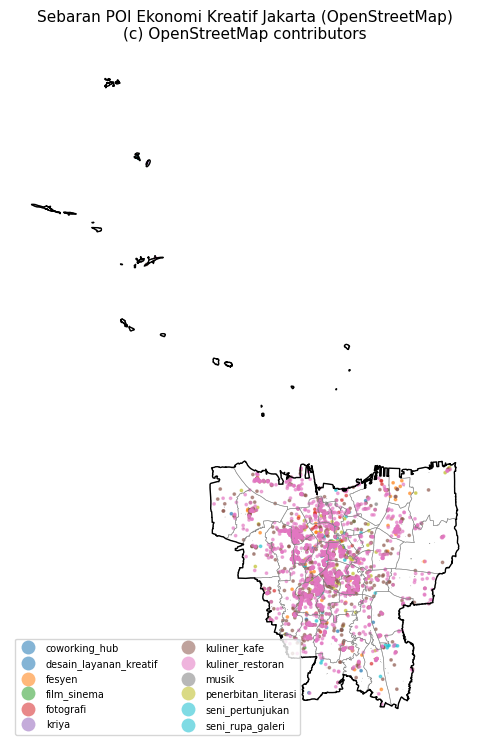

=== RINGKASAN TAHAP 1 ===
POI berlabel : 2924  | unik: 2924
Subsektor    : 12/12
Kecamatan    : 200  | Luas: 648.9 km2
Output       : <folder-proyek>/data/processed

File untuk Tahap 2: poi_creative.gpkg (layer poi/poi_unique/poi_kecamatan),
  jakarta_studyarea.gpkg (kecamatan), populasi_kecamatan.csv, worldpop_jakarta.tif


In [7]:
assert "RAW" in globals(), "Jalankan SEL 1 (SETUP) dulu: Kernel > Restart, lalu jalankan sel pertama."
assert "poi" in globals(), "Jalankan SEL 3-4 dulu."

fig, ax = plt.subplots(figsize=(11, 9))
kecamatan.boundary.plot(ax=ax, color="grey", linewidth=0.4, alpha=0.8)
gpd.GeoDataFrame(geometry=[study_area], crs=CRS_GEO).boundary.plot(ax=ax, color="black", linewidth=1.0)
poi.plot(ax=ax, column="subsector", categorical=True, markersize=3, legend=True, alpha=0.55,
         legend_kwds={"fontsize": 7, "loc": "lower left", "ncol": 2})
ax.set_title("Sebaran POI Ekonomi Kreatif Jakarta (OpenStreetMap)\n(c) OpenStreetMap contributors", fontsize=11)
ax.set_axis_off()
fig.savefig(FIG / "poi_overview.png", dpi=150, bbox_inches="tight")
plt.show()

with open(PROC / "provenance.json", "w", encoding="utf-8") as f:
    json.dump(PROVENANCE, f, indent=2, ensure_ascii=False)

print("=== RINGKASAN TAHAP 1 ===")
print(f"POI berlabel : {len(poi)}  | unik: {len(poi_unique)}")
print(f"Subsektor    : {poi['subsector'].nunique()}/{len(TAXONOMY)}")
print(f"Kecamatan    : {len(kecamatan)}  | Luas: {luas:,.1f} km2")
print(f"Output       : {PROC}")
print("\nFile untuk Tahap 2: poi_creative.gpkg (layer poi/poi_unique/poi_kecamatan),")
print("  jakarta_studyarea.gpkg (kecamatan), populasi_kecamatan.csv, worldpop_jakarta.tif")
